<a href="https://colab.research.google.com/github/fahimaislam2022/Python-/blob/main/1C_Logistic_Regression_using_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import minimize

df = pd.read_csv('/content/ex2data1.csv', header=None)
df.rename(columns={0: 'exam1', 1:'exam2', 2:'y'}, inplace=True)
df.head()



,exam1,exam2,y
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


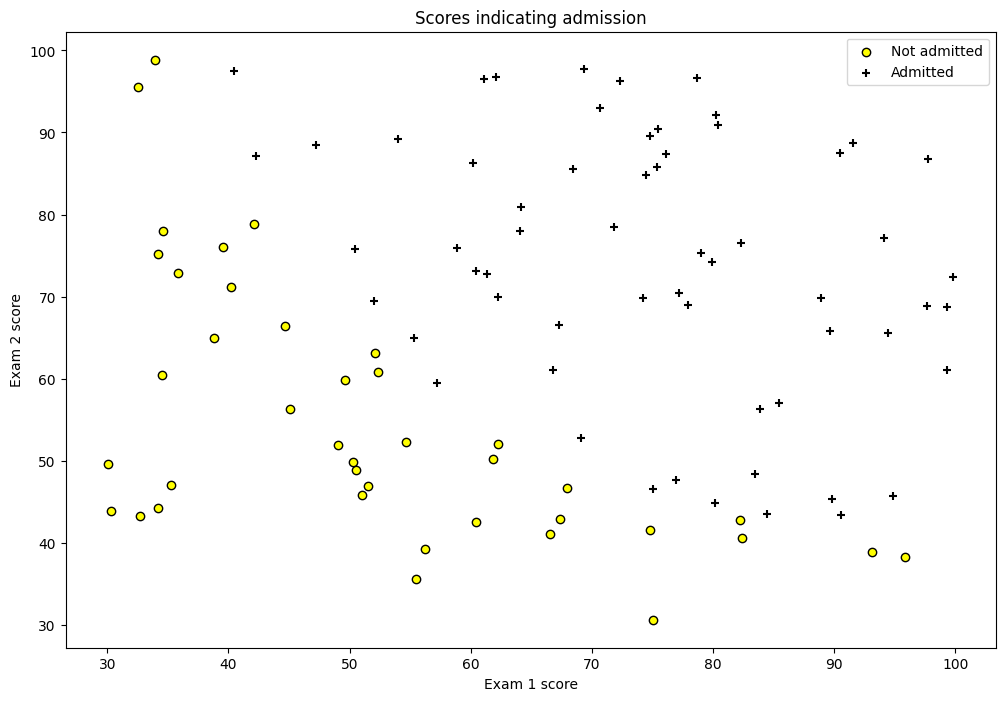

In [4]:
fig = plt.figure(figsize=(12, 8))
plt.scatter(df[df['y'] == 0]['exam1'], df[df['y'] == 0]['exam2'], label='Not admitted', color='yellow', edgecolor='black')
plt.scatter(df[df['y'] == 1]['exam1'], df[df['y'] == 1]['exam2'], label='Admitted', marker='+', color='black')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(loc='upper right')
plt.title('Scores indicating admission')
plt.show()

In [35]:
class LogisticRegression(object):
  def __init__(self, X, y, alpha=0.001, n_iteration=5000):
    self.X = self._hstack_one(X)
    self.y = y
    self.thetas = np.zeros((self.X.shape[1]))
    self.n_rows = self.X.shape[0]
    self.alpha = alpha
    self.n_iterations = n_iteration

    print("Cost before fitting: {0:.4f}".format(self.cost()))

  @staticmethod
  def _hstack_one(input_matrix):
    if len(input_matrix.shape) == 1:
      return np.hstack((np.array([1]), input_matrix))
    else:
      return np.hstack(
          (np.ones((input_matrix.shape[0], 1)), input_matrix))

  @staticmethod
  def sigmoid(X):
    return 1 / (1 + np.exp(-X))

  def cost(self, thetas=None):
    if thetas is None:
        thetas = self.thetas
    dot_prod = self.X.dot(thetas)
    dot_prod_pos = dot_prod[self.y == 1]
    dot_prod_neg = dot_prod[self.y == 0]
    cost = -(1/ self.n_rows) \
            *(np.sum(np.log(self.sigmoid(dot_prod_pos)))
               + np.sum(np.log(1 - self.sigmoid(dot_prod_neg))))
    return cost

  def predict(self, new_X, thershold=0.5):

    assert new_X.shape[1] == self.X.shape[1] - 1, \
        "Expected new_X to have {} columns, but got {}".format(self.X.shape[1] - 1, new_X.shape[1])
    new_X = self._hstack_one(new_X)
    h = new_X.dot(self.thetas)
    return self.sigmoid(h) >= thershold

  def batch_gradient(self, thetas=None):
    if thetas is None:
        thetas = self.thetas
    h = self.sigmoid(self.X.dot(thetas)) - self.y
    h = np.multiply(self.X, h.reshape(-1, 1))
    h = np.sum(h, axis=0)
    return h

  def batch_gradient_descent(self, ):

    alpha_by_m = self.alpha / self.n_rows
    for i in range(self.n_iterations):
      self.thetas = self.thetas - (alpha_by_m * self.batch_gradient())
      cost = self.cost()

      print("\rIteration: {0} Loss: {1: .5f}".format(i + 1, cost), end='')
    print()


  def scipy_optimize(self, ):
    result = minimize(self.cost, self.thetas, jac=self.batch_gradient,
                      options={'maxiter': self.n_iterations})

    print(result)
    self.thetas = result.x

In [36]:
lr = LogisticRegression(df[['exam1', 'exam2']].values, df['y'].values, n_iteration=2000, alpha=0.001)
optim_thetas = lr.scipy_optimize()
print ("Cost after coverging: {0:.3f}".format(lr.cost()))

Cost before fitting: 0.6931
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.20349770159874905
        x: [-2.516e+01  2.062e-01  2.015e-01]
      nit: 73
      jac: [-9.709e-07 -6.306e-05 -6.691e-05]
 hess_inv: [[ 2.204e+01 -1.786e-01 -1.906e-01]
            [-1.786e-01  1.517e-03  1.481e-03]
            [-1.906e-01  1.481e-03  1.719e-03]]
     nfev: 297
     njev: 281
Cost after coverging: 0.203


/tmp/ipykernel_1740/2377430534.py:32: RuntimeWarning: divide by zero encountered in log
  + np.sum(np.log(1 - self.sigmoid(dot_prod_neg))))
/tmp/ipykernel_1740/2377430534.py:32: RuntimeWarning: divide by zero encountered in log
  + np.sum(np.log(1 - self.sigmoid(dot_prod_neg))))


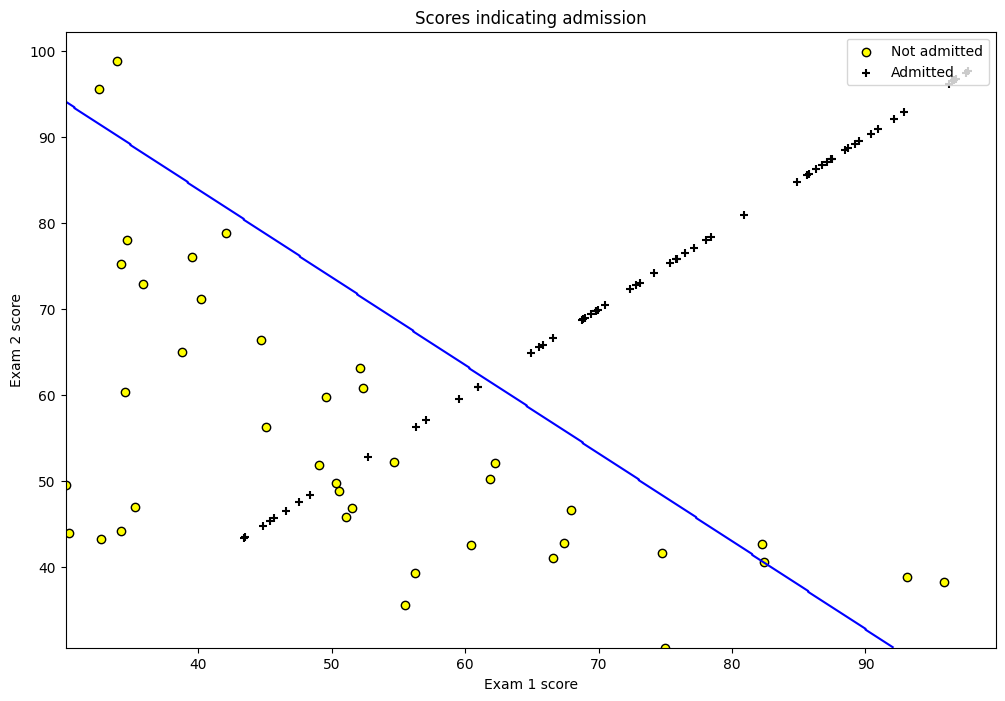

In [39]:
col1 = "exam1"
col2 = "exam2"
min_ex1 = df[col1].min()
max_ex1 = df[col1].max()

min_ex2 = df[col2].min()
max_ex2 = df[col2].max()

arange_step = 0.1

xx, yy = np.meshgrid(np.arange(min_ex1, max_ex1, arange_step),
                     np.arange(min_ex2, max_ex2, arange_step))
preds = np.c_[xx.ravel(), yy.ravel()]
preds = lr.predict(preds)
preds = preds.reshape(xx.shape)
fig = plt.figure(figsize=(12, 8))
plt.scatter(df[df['y'] == 0][col1], df[df['y'] == 0][col2], label='Not admitted', color='yellow', edgecolor='black')
plt.scatter(df[df['y'] == 1][col2], df[df['y'] == 1][col2], label='Admitted', marker='+', color='black')
plt.contour(xx, yy, preds, colors='blue')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(loc='upper right')
plt.title('Scores indicating admission')
plt.show()